# Operations on the Integers - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-2/operations-on-integers.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### Addition

Two separate shifts.

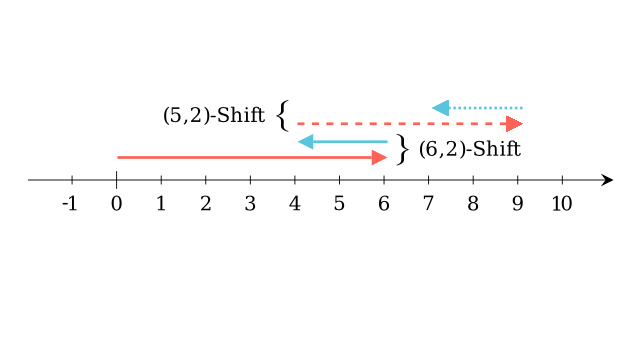

In [29]:
%%generate_image addition-number-line_separate NumberLineDiagram

FONT_SIZE = 32


class NumberLineDiagram(Scene):
    def construct(self):
        # Create the line
        line = NumberLine(
            x_range=[-1.99, 10.99, 1],
            color=BLACK,
            numbers_with_elongated_ticks=[0],
            include_numbers=True,
            label_constructor=Text,
            font_size=FONT_SIZE,
            line_to_number_buff=0.35
        )
        for n in line.numbers:
            n.set_color(BLACK)
        line.add_tip(tip_shape=StealthTip, tip_length=0.2)

        self.add(line)

        # Add arrows for 4 (represented by the shift (6, 2))
        four_group = VGroup(
            Arrow(line.n2p(0), line.n2p(6), color=RED, buff=0),
            Arrow(line.n2p(6), line.n2p(4), color=BLUE, buff=0).shift(0.35*UP)
        )
        four_group.shift(0.5*UP)
        self.add(four_group)

        # Add arrows for 3 (represented by the shift (5, 2))
        three_group = VGroup(
            DashedVMobject(Arrow(line.n2p(4), line.n2p(9), color=RED, buff=0)),
            DashedVMobject(Arrow(line.n2p(9), line.n2p(7), color=BLUE, buff=0)).shift(0.35*UP)
        )
        three_group.shift(1.25*UP)
        self.add(three_group)

        # Add braces and labels
        four_group_brace = Brace(four_group, direction=RIGHT, color=BLACK)
        four_group_brace.add(
            Text(
                "(6,2)-Shift",
                font_size=FONT_SIZE,
                color=BLACK
            ).next_to(four_group_brace, RIGHT)
        )
        self.add(four_group_brace)

        three_group_brace = Brace(three_group, direction=LEFT, color=BLACK)
        three_group_brace.add(
            Text(
                "(5,2)-Shift",
                font_size=FONT_SIZE,
                color=BLACK
            ).next_to(three_group_brace, LEFT)
        )
        self.add(three_group_brace)

As two parts of the same shift.

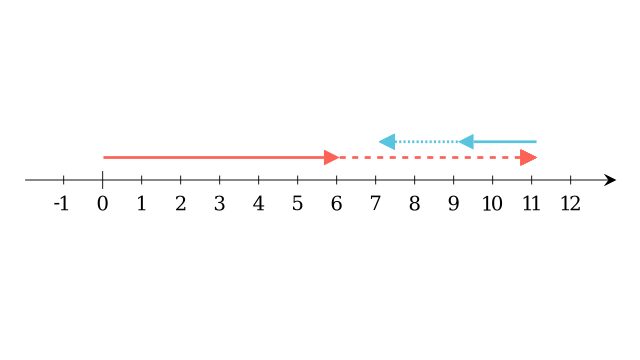

In [38]:
%%generate_image addition-number-line_combined NumberLineDiagram

FONT_SIZE = 32


class NumberLineDiagram(Scene):
    def construct(self):
        # Create the line
        line = NumberLine(
            x_range=[-1.99, 12.99, 1],
            unit_size=0.875,
            color=BLACK,
            numbers_with_elongated_ticks=[0],
            include_numbers=True,
            label_constructor=Text,
            font_size=FONT_SIZE,
            line_to_number_buff=0.35
        )
        for n in line.numbers:
            n.set_color(BLACK)
        line.add_tip(tip_shape=StealthTip, tip_length=0.2)

        self.add(line)

        # Add arrows for rightward shift (6 and 5)
        rightward_group = VGroup(
            Arrow(line.n2p(0), line.n2p(6), color=RED, buff=0),
            DashedVMobject(Arrow(line.n2p(6), line.n2p(11), color=RED, buff=0))
        )
        rightward_group.shift(0.5*UP)
        self.add(rightward_group)

        # Add arrows for leftward shift (2 and 2)
        leftward_group = VGroup(
            Arrow(line.n2p(11), line.n2p(9), color=BLUE, buff=0),
            DashedVMobject(Arrow(line.n2p(9), line.n2p(7), color=BLUE, buff=0))
        )
        leftward_group.shift(0.85*UP)
        self.add(leftward_group)

### TODO

Diagram showing the effect of the mapping
$$
    f(x) = \begin{cases}
        2x & x \geq 0\\
        -(2x+1) & x < 0
    \end{cases}
$$
to prove injection from $\mathbb{Z}$ to $\mathbb{N}$.

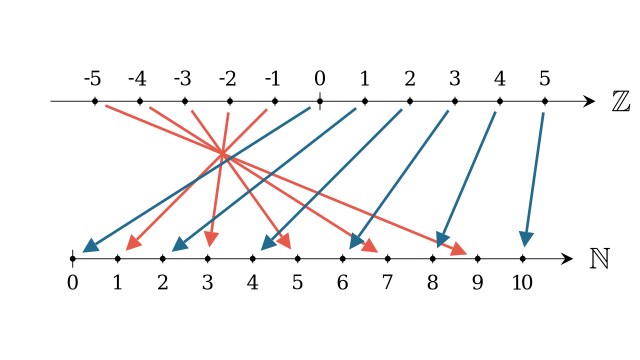

In [65]:
%%generate_image equinumerosity-line NumberLineDiagram
    
FONT_SIZE = 32

INTEGER_LINE_RANGE = (-5.99, 5.99)
INTEGER_LINE_INTS = list(range(int(np.ceil(INTEGER_LINE_RANGE[0])), int(np.floor(INTEGER_LINE_RANGE[1])) + 1))
NATURAL_LINE_RANGE = (0, len(INTEGER_LINE_INTS) - 1)
NATURAL_LINE_INTS = range(len(INTEGER_LINE_INTS))


class NumberLineDiagram(Scene):
    def construct(self):
        # Create the lines
        integer_line = NumberLine(
            x_range=[*INTEGER_LINE_RANGE, 1],
            color=BLACK,
            numbers_with_elongated_ticks=[0],
            include_numbers=True,
            label_constructor=Text,
            font_size=FONT_SIZE,
            line_to_number_buff=0.35
        )
        integer_line.shift(1.75*UP)
        integer_line.add(
            MathTex(
                r"\mathbb{Z}", 
                color=BLACK, 
                font_size=2*FONT_SIZE
            ).next_to(integer_line, RIGHT).shift(0.25*UP+0.25*RIGHT)
        )
        
        natural_line = NumberLine(
            x_range=[NATURAL_LINE_RANGE[0], NATURAL_LINE_RANGE[1] + 0.99, 1],
            color=BLACK,
            numbers_with_elongated_ticks=[0],
            include_numbers=True,
            label_constructor=Text,
            font_size=FONT_SIZE,
            line_to_number_buff=0.35
        )
        natural_line.shift(1.75*DOWN)
        natural_line.add(
            MathTex(
                r"\mathbb{N}", 
                color=BLACK, 
                font_size=2*FONT_SIZE
            ).next_to(natural_line, RIGHT).shift(0.25*UP+0.25*RIGHT)
        )
        
        for line in (integer_line, natural_line):
            for n in line.numbers:
                n.set_color(BLACK)
                if line == integer_line:
                    flip_about_line(n, integer_line, handle_orientation=False)

            # Add tip this way to position the dots correctly
            line.add(
                StealthTip(
                    length=0.2, color=BLACK
                ).move_to(line.n2p(line.x_range[1]))
            )

        self.add(integer_line, natural_line)
            
        # Add mapping arrows
        for x in INTEGER_LINE_INTS:
            # Get the resultant natural number
            map_type = None
            if x >= 0:
                y = 2 * x
                map_type = "non-neg"
            else:
                y = -(2*x + 1)
                map_type = "neg"

            # Add the dots
            start = integer_line.n2p(x)
            end = natural_line.n2p(y)

            self.add(Dot(start, color=BLACK, radius=0.065))
            self.add(Dot(end, color=BLACK, radius=0.065))
            
            # Draw the arrow
            arrow = Arrow(
                start,
                end,
                color=BLUE_E if map_type == "non-neg" else RED_D
            )
            self.add(arrow)
    